# dots.ocr on the Draftly corpus

Testing [dots.ocr](https://github.com/studio-dots-ai/dots.ocr) — a 3B
vision-language model that does **layout detection and text recognition in one
pass**, prompt-driven — against the matter bundles in `ocr-benchmark/cases/`,
and head-to-head with the two engines already benchmarked.

## Why this one is worth the trouble

Three reasons, in order of importance to this project.

**1. Sinhala.** This is the blocker every other engine has hit. RapidOCR reads
Latin only. docTR reads Latin only — it produced confident Latin words from
Sinhala glyphs, which is worse than reading nothing. dots.ocr's stated goal is
to *"recognize virtually any human script"*, and its model card is tagged
`multilingual`. If that holds for Sinhala it changes what the whole pipeline can
do, because no amount of agent architecture recovers text that was never
recognised.

**2. It is MIT licensed.** Surya is GPL-3.0 and is parked pending a ruling, since
the platform already rejected PyMuPDF on AGPL grounds. dots.ocr raises no such
question.

**3. Layout and reading order come free.** It returns `bbox`, a category from a
fixed set, and text, already sorted in human reading order. That directly fills
two gaps flagged elsewhere in this benchmark: the RaV-IDP entity router (a
geometry heuristic standing in for a trained layout model) and the MADP Parser
Agent's reading-order reconstruction.

## The hardware problem, stated up front

The model is **3.04B parameters in BF16 ≈ 6.1 GB of weights**, before
activations. This machine has 16 GB of RAM, no GPU, and has been running at
1–2 GB free. Running it locally on CPU means roughly 9 GB resident and minutes of
generation per page.

So the notebook supports three backends and checks before it tries:

| Backend | When to use |
|---|---|
| `server` | A vLLM or any OpenAI-compatible endpoint. **Preferred.** |
| `local` | `transformers` on this machine. Needs ~9 GB free; slow. |
| `none` | No backend reachable — the notebook still runs and reports what it would do. |

The realistic path today is a free Colab/Kaggle T4: 16 GB of VRAM fits this
comfortably in bf16. A ready-to-paste cell is near the bottom.

In [1]:
from __future__ import annotations

import base64, gc, io, json, math, os, re, sys, time
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Sequence

os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "ocr-benchmark" else Path.cwd() / "ocr-benchmark"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import config, contract, normalize, render, viz

viz.use_style()
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)

MODEL_ID = "dots-studio/dots.ocr"     # dots-studio/dots.mocr is the newer variant
DPI = 200
VARIANT = "original"
MAX_PAGES_PER_DOC = 2

CACHE = config.RENDERS / "engine-cache"    # shared with the other engine notebooks
(CACHE / "dotsocr").mkdir(parents=True, exist_ok=True)


def free_ram_gb() -> float:
    try:
        import ctypes
        class S(ctypes.Structure):
            _fields_ = [("dwLength", ctypes.c_ulong), ("dwMemoryLoad", ctypes.c_ulong),
                        ("ullTotalPhys", ctypes.c_ulonglong), ("ullAvailPhys", ctypes.c_ulonglong),
                        ("ullTotalPageFile", ctypes.c_ulonglong), ("ullAvailPageFile", ctypes.c_ulonglong),
                        ("ullTotalVirtual", ctypes.c_ulonglong), ("ullAvailVirtual", ctypes.c_ulonglong),
                        ("ullAvailExtendedVirtual", ctypes.c_ulonglong)]
        s = S(); s.dwLength = ctypes.sizeof(S)
        ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(s))
        return s.ullAvailPhys / 1024 ** 3
    except Exception:
        return float("inf")


print(f"free RAM: {free_ram_gb():.1f} GB   (model needs ~9 GB resident on CPU)")
for case in config.case_dirs():
    print(f"  {case.name:45s} {len(config.case_documents(case)):3d} documents")

free RAM: 1.9 GB   (model needs ~9 GB resident on CPU)
  platform-case-001                               7 documents
  research-case-001-rajagiriya-dalgahawatta      24 documents
  research-case-002-maharagama-assessment         6 documents
  research-case-003-sc-fr-319-2024                1 documents


## Their prompts, verbatim

Copied from `dots_ocr/utils/prompts.py` rather than paraphrased — the model is
trained against these exact strings, so rewording them degrades output for no
reason.

In [2]:
PROMPTS = {
    "prompt_layout_all_en": """Please output the layout information from the PDF image, including each layout element's bbox, its category, and the corresponding text content within the bbox.

1. Bbox format: [x1, y1, x2, y2]

2. Layout Categories: The possible categories are ['Caption', 'Footnote', 'Formula', 'List-item', 'Page-footer', 'Page-header', 'Picture', 'Section-header', 'Table', 'Text', 'Title'].

3. Text Extraction & Formatting Rules:
    - Picture: For the 'Picture' category, the text field should be omitted.
    - Formula: Format its text as LaTeX.
    - Table: Format its text as HTML.
    - All Others (Text, Title, etc.): Format their text as Markdown.

4. Constraints:
    - The output text must be the original text from the image, with no translation.
    - All layout elements must be sorted according to human reading order.

5. Final Output: The entire output must be a single JSON object.
""",
    "prompt_layout_only_en": """Please output the layout information from this PDF image, including each layout's bbox and its category. The bbox should be in the format [x1, y1, x2, y2]. The layout categories for the PDF document include ['Caption', 'Footnote', 'Formula', 'List-item', 'Page-footer', 'Page-header', 'Picture', 'Section-header', 'Table', 'Text', 'Title']. Do not output the corresponding text. The layout result should be in JSON format.""",
    "prompt_ocr": """Extract the text content from this image.""",
}

LAYOUT_CATEGORIES = ["Caption", "Footnote", "Formula", "List-item", "Page-footer",
                     "Page-header", "Picture", "Section-header", "Table", "Text", "Title"]

# dots_ocr/utils/consts.py
MIN_PIXELS, MAX_PIXELS, IMAGE_FACTOR = 3136, 11289600, 28


def smart_resize(width: int, height: int, factor: int = IMAGE_FACTOR,
                 min_pixels: int = MIN_PIXELS, max_pixels: int = MAX_PIXELS) -> tuple[int, int]:
    """Qwen2-VL smart resize: both sides multiples of `factor`, area within bounds.

    Matters because the model returns pixel boxes in the RESIZED frame. Getting
    this wrong silently misplaces every bounding box while still looking sane.
    """
    h_bar = max(factor, round(height / factor) * factor)
    w_bar = max(factor, round(width / factor) * factor)
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = max(factor, math.floor(height / beta / factor) * factor)
        w_bar = max(factor, math.floor(width / beta / factor) * factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = math.ceil(height * beta / factor) * factor
        w_bar = math.ceil(width * beta / factor) * factor
    return w_bar, h_bar


print("prompt modes:", list(PROMPTS))
print("categories  :", len(LAYOUT_CATEGORIES))
print("smart_resize(1653, 2339) ->", smart_resize(1653, 2339))

prompt modes: ['prompt_layout_all_en', 'prompt_layout_only_en', 'prompt_ocr']
categories  : 11
smart_resize(1653, 2339) -> (1652, 2352)


## Backend selection

`server` first, because it is the only option that is fast here. Point
`DOTS_OCR_BASE_URL` at a vLLM instance:

```bash
vllm serve dots-studio/dots.ocr --trust-remote-code --port 8000
```

```powershell
$env:DOTS_OCR_BASE_URL = "http://localhost:8000/v1"
```

In [3]:
BASE_URL = os.environ.get("DOTS_OCR_BASE_URL", "").strip()
API_KEY = os.environ.get("DOTS_OCR_API_KEY", "EMPTY").strip()
FORCE_LOCAL = False          # True = attempt CPU inference regardless of free RAM
MIN_LOCAL_GB = 9.0


def choose_backend() -> tuple[str, str]:
    if BASE_URL:
        try:
            import urllib.request
            with urllib.request.urlopen(f"{BASE_URL.rstrip('/')}/models", timeout=5) as r:
                if r.status == 200:
                    return "server", f"reachable at {BASE_URL}"
        except Exception as exc:
            return "none", f"DOTS_OCR_BASE_URL set but unreachable: {type(exc).__name__}"
    try:
        import torch          # noqa: F401
        import transformers   # noqa: F401
    except ImportError:
        return "none", "transformers/torch not installed and no server configured"
    free = free_ram_gb()
    if free < MIN_LOCAL_GB and not FORCE_LOCAL:
        return "none", (f"only {free:.1f} GB free; a 3.04B BF16 model needs ~{MIN_LOCAL_GB:.0f} GB "
                        "resident. Set FORCE_LOCAL=True to try anyway (it will likely be killed).")
    return "local", f"transformers on CPU, {free:.1f} GB free"


BACKEND, WHY = choose_backend()
print(f"backend: {BACKEND}")
print(f"reason : {WHY}")
if BACKEND == "none":
    print("\nThe notebook still runs: it renders pages, reports what it would send, and")
    print("compares the other engines. Only the dots.ocr columns stay empty.")

d:\projects\Draftly-Project\draftly-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


backend: none
reason : only 1.9 GB free; a 3.04B BF16 model needs ~9 GB resident. Set FORCE_LOCAL=True to try anyway (it will likely be killed).

The notebook still runs: it renders pages, reports what it would send, and
compares the other engines. Only the dots.ocr columns stay empty.


In [4]:
_MODEL = None
_PROCESSOR = None


def _load_local():
    global _MODEL, _PROCESSOR
    if _MODEL is None:
        import torch
        from transformers import AutoModelForCausalLM, AutoProcessor
        began = time.time()
        _MODEL = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, trust_remote_code=True, dtype=torch.bfloat16, device_map="cpu")
        _PROCESSOR = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
        print(f"loaded {MODEL_ID} in {time.time() - began:.0f}s")
    return _MODEL, _PROCESSOR


def _b64(image: Image.Image) -> str:
    buffer = io.BytesIO()
    image.convert("RGB").save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode()


def run_dots(image: Image.Image, mode: str = "prompt_layout_all_en",
             max_tokens: int = 8192) -> tuple[str, float]:
    """Return (raw_model_text, seconds). Resizing follows their smart_resize."""
    target = smart_resize(*image.size)
    resized = image.convert("RGB").resize(target, Image.LANCZOS)
    prompt = PROMPTS[mode]
    began = time.time()

    if BACKEND == "server":
        import urllib.request
        payload = json.dumps({
            "model": MODEL_ID,
            "messages": [{"role": "user", "content": [
                {"type": "image_url",
                 "image_url": {"url": f"data:image/png;base64,{_b64(resized)}"}},
                {"type": "text", "text": prompt},
            ]}],
            "max_tokens": max_tokens,
            "temperature": 0.0,
        }).encode()
        request = urllib.request.Request(
            f"{BASE_URL.rstrip('/')}/chat/completions", data=payload,
            headers={"Content-Type": "application/json",
                     "Authorization": f"Bearer {API_KEY}"})
        with urllib.request.urlopen(request, timeout=900) as response:
            body = json.loads(response.read())
        return body["choices"][0]["message"]["content"], time.time() - began

    if BACKEND == "local":
        model, processor = _load_local()
        messages = [{"role": "user", "content": [
            {"type": "image", "image": resized}, {"type": "text", "text": prompt}]}]
        text = processor.apply_chat_template(messages, tokenize=False,
                                             add_generation_prompt=True)
        inputs = processor(text=[text], images=[resized], return_tensors="pt")
        generated = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False)
        trimmed = generated[0][inputs["input_ids"].shape[1]:]
        return processor.decode(trimmed, skip_special_tokens=True), time.time() - began

    raise RuntimeError(f"no dots.ocr backend available: {WHY}")


def parse_dots(raw: str, resized: tuple[int, int]) -> list[dict[str, Any]]:
    """Their JSON output -> our normalized bbox contract.

    Their boxes are PIXELS in the RESIZED frame, so they divide by the resized
    dimensions, not the original. Getting that wrong puts every box in the wrong
    place while still looking plausible.
    """
    text = re.sub(r"^```(?:json)?|```$", "", raw.strip(), flags=re.M).strip()
    try:
        payload = json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\[.*\]|\{.*\}", text, re.S)
        if not match:
            return []
        try:
            payload = json.loads(match.group(0))
        except json.JSONDecodeError:
            return []

    items = payload if isinstance(payload, list) else (
        payload.get("layout") or payload.get("elements") or payload.get("results") or [])
    rw, rh = resized
    out = []
    for item in items:
        if not isinstance(item, dict):
            continue
        box = item.get("bbox") or item.get("box")
        if not box or len(box) != 4:
            continue
        x0, y0, x1, y1 = (float(v) for v in box)
        out.append({
            "bbox": list(contract.clamp_bbox((x0 / rw, y0 / rh, x1 / rw, y1 / rh))),
            "category": str(item.get("category") or item.get("label") or "Text"),
            "text": str(item.get("text") or ""),
        })
    return out


# Parser check on a synthetic response, so it is verified without a backend.
_demo = '```json\n[{"bbox":[140,280,700,340],"category":"Title","text":"CERTIFICATE"}]\n```'
_parsed = parse_dots(_demo, (1400, 2800))
print("parser check:", _parsed)
assert _parsed and _parsed[0]["category"] == "Title"
assert abs(_parsed[0]["bbox"][0] - 0.1) < 1e-9, "bbox must normalize against the RESIZED frame"
print("inference wired for backend:", BACKEND)

parser check: [{'bbox': [0.1, 0.1, 0.5, 0.12142857142857143], 'category': 'Title', 'text': 'CERTIFICATE'}]
inference wired for backend: none


## Run over the corpus

Results are cached per page, so a re-run costs nothing. RapidOCR and docTR
results come from the shared cache written by `doctr_trial.ipynb`, so all three
engines are compared on identical pixels.

In [5]:
MATTER = "platform-case-001"    # the labelled matter; None for all four


def dots_cache(doc_id: str, page_no: int) -> Path:
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    return CACHE / "dotsocr" / safe / f"p{page_no:04d}@{DPI}-{VARIANT}.json"


def other_engine_text(doc_id: str, page_no: int, engine: str) -> str | None:
    """Read a cached RapidOCR/docTR page result if one exists."""
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    path = CACHE / engine / safe / f"p{page_no:04d}@{DPI}-{VARIANT}.json"
    if not path.is_file():
        return None
    words = json.loads(path.read_text(encoding="utf-8"))["words"]
    ordered = sorted(words, key=lambda w: (w["bbox"][1], w["bbox"][0]))
    return "\n".join(w["text"] for w in ordered)


cases = [c for c in config.case_dirs() if MATTER is None or c.name == MATTER]
documents = [d for c in cases for d in config.case_documents(c)]

records: list[dict[str, Any]] = []
for doc in documents:
    doc_id = f"{doc.parent.name}/{doc.name}"
    for page in render.render_doc(doc, dpi=DPI, variant=VARIANT, page_limit=MAX_PAGES_PER_DOC):
        row: dict[str, Any] = {"doc_id": doc_id,
                               "document": doc.stem.replace("source-", "")[:32],
                               "page": page.page_no, "dots_seconds": None, "dots_error": ""}

        cached = dots_cache(doc_id, page.page_no)
        elements: list[dict[str, Any]] = []
        if cached.is_file():
            payload = json.loads(cached.read_text(encoding="utf-8"))
            elements, row["dots_seconds"] = payload["elements"], payload["seconds"]
        elif BACKEND != "none":
            try:
                raw, seconds = run_dots(page.image)
                elements = parse_dots(raw, smart_resize(*page.image.size))
                cached.parent.mkdir(parents=True, exist_ok=True)
                cached.write_text(json.dumps({"elements": elements,
                                              "seconds": round(seconds, 2)},
                                             ensure_ascii=False), encoding="utf-8")
                row["dots_seconds"] = round(seconds, 2)
            except Exception as exc:
                row["dots_error"] = f"{type(exc).__name__}: {exc}"[:160]

        dots_text = "\n".join(e["text"] for e in elements if e["text"].strip())
        row["dots_elements"] = len(elements)
        row["dots_chars"] = len(re.sub(r"\s+", "", dots_text))
        row["dots_text"] = dots_text
        row["categories"] = Counter(e["category"] for e in elements)

        for engine in ("rapidocr", "doctr"):
            text = other_engine_text(doc_id, page.page_no, engine)
            row[f"{engine}_chars"] = None if text is None else len(re.sub(r"\s+", "", text))
            row[f"{engine}_text"] = text or ""

        records.append(row)
        page.image.close()
        gc.collect()
    print(f"  {doc.name[:50]:52s} pages done")

df = pd.DataFrame(records)
print(f"\n{len(df)} pages")
if len(df) and df["dots_error"].str.len().sum():
    print("errors:", df[df.dots_error != ""]["dots_error"].unique()[:3])
display(df[["document", "page", "dots_elements", "dots_chars",
            "rapidocr_chars", "doctr_chars"]] if len(df) else "nothing processed")

  source-001-national-identity-card.pdf                pages done
  source-002-survey-plan-2338-lot-17-18-extracts.pdf   pages done
  source-003-title-certificate-parcel-0021.pdf         pages done
  source-004-form8-instrument-of-transfer-with-stamp   pages done
  source-005-rta-sale-instrument-sinhala-registered.   pages done
  source-006-vendor-board-resolution-lot-20.pdf        pages done
  source-007-payment-cheque-part-consideration.pdf     pages done

12 pages


,document,page,dots_elements,dots_chars,rapidocr_chars,doctr_chars
0,001-national-identity-card,1,0,0,71,57
1,001-national-identity-card,2,0,0,142,212
2,002-survey-plan-2338-lot-17-18-e,1,0,0,1535,367
3,002-survey-plan-2338-lot-17-18-e,2,0,0,1545,396
4,003-title-certificate-parcel-002,1,0,0,633,943
5,003-title-certificate-parcel-002,2,0,0,298,216
6,004-form8-instrument-of-transfer,1,0,0,691,686
7,004-form8-instrument-of-transfer,2,0,0,989,1039
8,005-rta-sale-instrument-sinhala-,1,0,0,549,1103
9,005-rta-sale-instrument-sinhala-,2,0,0,636,1403


## The headline question: does it read Sinhala?

This decides whether dots.ocr matters here. Neither existing engine can read
Sinhala, and roughly half this corpus is Sinhala.

Character volume will not answer it — docTR already emits plenty of confident
Latin characters from Sinhala pages. The test is whether the output is **in the
Sinhala script at all**, measured by Unicode block.

In [6]:
def sinhala_ratio(text: str) -> float:
    """Share of letters that are Sinhala codepoints. The honest test."""
    if not text:
        return 0.0
    sinhala = len(re.findall(r"[\u0D80-\u0DFF]", text))
    latin = len(re.findall(r"[A-Za-z]", text))
    total = sinhala + latin
    return sinhala / total if total else 0.0


ENGINES = ["dots", "doctr", "rapidocr"]

if len(df):
    for engine in ENGINES:
        col = f"{engine}_text"
        if col in df:
            df[f"{engine}_sinhala"] = df[col].fillna("").map(sinhala_ratio)

    print("mean share of letters that are Sinhala codepoints:\n")
    print(df[[f"{e}_sinhala" for e in ENGINES if f"{e}_sinhala" in df]].mean().round(4).to_string())
    print()
    hits = {e: int((df[f"{e}_sinhala"] > 0.05).sum()) for e in ENGINES if f"{e}_sinhala" in df}
    print(f"pages with meaningful Sinhala output: {hits}  of {len(df)}")
    if BACKEND == "none":
        print("\ndots.ocr did not run, so its column is structurally zero. That is a")
        print("missing measurement, NOT a finding about the model.")
    elif hits.get("dots", 0) == 0:
        print("\ndots.ocr produced no Sinhala. Either the pages sampled are English, or")
        print("the multilingual claim does not extend to Sinhala. Check a known-Sinhala")
        print("page (source-005 is the registered Sinhala RTA instrument) before concluding.")

mean share of letters that are Sinhala codepoints:

dots_sinhala        0.0
doctr_sinhala       0.0
rapidocr_sinhala    0.0

pages with meaningful Sinhala output: {'dots': 0, 'doctr': 0, 'rapidocr': 0}  of 12

dots.ocr did not run, so its column is structurally zero. That is a
missing measurement, NOT a finding about the model.


findfont: Failed to find font weight 600, now using 700.


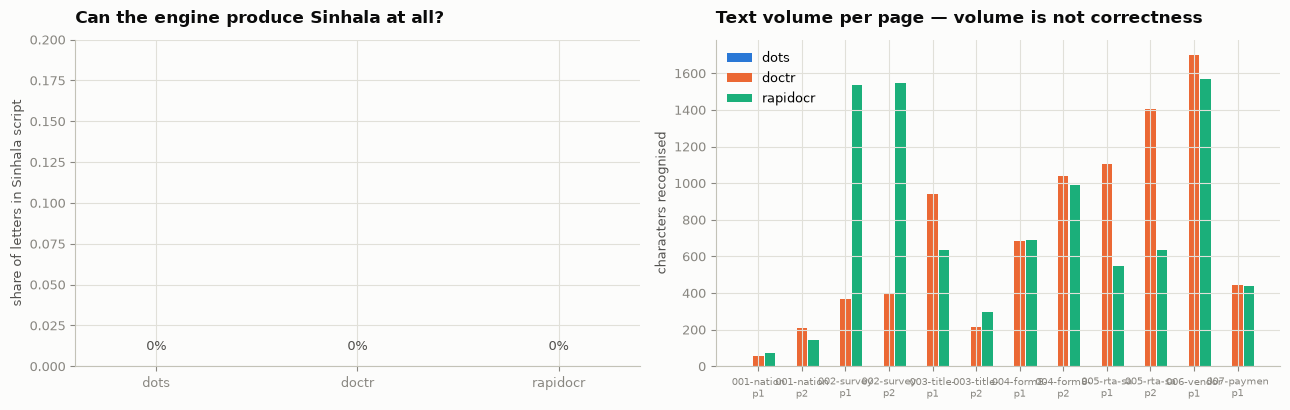

In [7]:
if len(df) and any(f"{e}_sinhala" in df for e in ENGINES):
    present = [e for e in ENGINES if f"{e}_sinhala" in df]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    ax = axes[0]
    x = np.arange(len(present))
    vals = [df[f"{e}_sinhala"].mean() for e in present]
    ax.bar(x, vals, 0.55, color=[viz.SERIES[i] for i in range(len(present))])
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center", color=viz.INK_2, fontsize=9)
    ax.set_xticks(x, present)
    ax.set_ylabel("share of letters in Sinhala script")
    ax.set_ylim(0, max(0.2, (max(vals) if vals else 0) * 1.35))
    ax.set_title("Can the engine produce Sinhala at all?")

    ax = axes[1]
    width = 0.8 / max(1, len(present))
    pages = np.arange(len(df))
    for i, e in enumerate(present):
        ax.bar(pages + i * width, df[f"{e}_chars"].fillna(0), width * 0.9,
               color=viz.SERIES[i], label=e)
    ax.set_xticks(pages + width, [f"{r.document[:10]}\np{r.page}" for r in df.itertuples()],
                  fontsize=7)
    ax.set_ylabel("characters recognised")
    ax.set_title("Text volume per page — volume is not correctness")
    ax.legend()

    plt.tight_layout(); plt.show()

## Critical-field recovery

The same measure used for docTR: does the ground-truth value appear verbatim in
what the engine read? Exact containment on the shared normalizer, never fuzzy —
a certificate number one digit out is a different title.

In [8]:
expected: dict[str, dict[str, Any]] = {}
for case in config.case_dirs():
    path = config.expected_fields_path(case)
    if path.is_file():
        for name, payload in json.loads(path.read_text(encoding="utf-8")).items():
            expected[f"{case.name}/{name}"] = payload

CRITICAL = set(json.loads((config.SCHEMAS / "critical-fields.json").read_text(encoding="utf-8"))["critical"])

doc_text: dict[tuple[str, str], str] = {}
if len(df):
    for doc_id, group in df.groupby("doc_id"):
        for engine in ENGINES:
            col = f"{engine}_text"
            if col in group:
                doc_text[(doc_id, engine)] = "\n".join(
                    t for t in group.sort_values("page")[col].fillna("") if t)

rows = []
for doc_id, payload in expected.items():
    for key, want in (payload.get("fields") or {}).items():
        for engine in ENGINES:
            text = doc_text.get((doc_id, engine))
            if not text:
                continue
            rows.append({"document": doc_id.split("/")[-1][:26], "field": key,
                         "critical": key in CRITICAL, "engine": engine,
                         "found": normalize.value_in_text(str(want), text)})

found = pd.DataFrame(rows)
if found.empty:
    print("no engine produced text for a labelled document yet")
else:
    pivot = (found.pivot_table(index="engine", columns="critical", values="found",
                               aggfunc="mean")
             .rename(columns={True: "critical", False: "non-critical"}) * 100).round(1)
    print("share of ground-truth values found verbatim (%):\n")
    print(pivot.to_string())
    print()
    print(found.groupby("engine")["found"].agg(["sum", "count"]).to_string())

share of ground-truth values found verbatim (%):

critical  non-critical  critical
engine                          
doctr             60.0      68.2
rapidocr          93.3      77.3

          sum  count
engine              
doctr      24     37
rapidocr   31     37


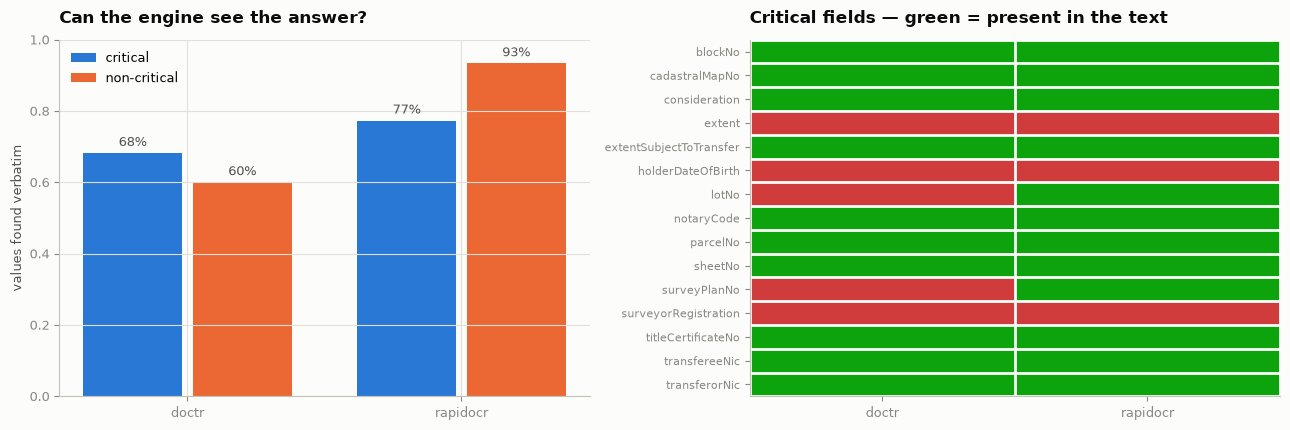

In [9]:
if not found.empty:
    present = [e for e in ENGINES if e in set(found["engine"])]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

    ax = axes[0]
    x = np.arange(len(present))
    crit = [found[(found.engine == e) & found.critical]["found"].mean() for e in present]
    non = [found[(found.engine == e) & ~found.critical]["found"].mean() for e in present]
    ax.bar(x - 0.2, crit, 0.36, color=viz.SERIES[0], label="critical")
    ax.bar(x + 0.2, non, 0.36, color=viz.SERIES[1], label="non-critical")
    for i, (c, n) in enumerate(zip(crit, non)):
        if not np.isnan(c):
            ax.text(i - 0.2, c + 0.02, f"{c:.0%}", ha="center", fontsize=9, color=viz.INK_2)
        if not np.isnan(n):
            ax.text(i + 0.2, n + 0.02, f"{n:.0%}", ha="center", fontsize=9, color=viz.INK_2)
    ax.set_xticks(x, present)
    ax.set_ylim(0, 1)
    ax.set_ylabel("values found verbatim")
    ax.set_title("Can the engine see the answer?")
    ax.legend()

    ax = axes[1]
    per_field = found[found.critical].pivot_table(index="field", columns="engine",
                                                  values="found", aggfunc="mean")
    if not per_field.empty:
        grid = np.nan_to_num(per_field.reindex(columns=present).to_numpy(dtype=float))
        cmap = plt.matplotlib.colors.ListedColormap([viz.STATUS["wrong"], viz.STATUS["correct"]])
        ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(present)), present)
        ax.set_yticks(range(len(per_field.index)), per_field.index, fontsize=8)
        ax.set_xticks(np.arange(-0.5, len(present), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(per_field.index), 1), minor=True)
        ax.grid(which="minor", color=viz.SURFACE, linewidth=2)
        ax.grid(which="major", visible=False)
        ax.tick_params(which="minor", length=0)
        ax.set_title("Critical fields — green = present in the text")
    plt.tight_layout(); plt.show()

## The layout output, the other reason to care

dots.ocr returns a category per region and orders elements by reading order. Two
places in this benchmark currently fake that: the RaV-IDP entity router (a
geometry heuristic) and the MADP Parser Agent (line grouping by vertical
overlap). If these categories are accurate, both can be replaced with a real
signal rather than a guess.

In [10]:
if len(df) and df["dots_elements"].sum():
    tally = Counter()
    for counter in df["categories"]:
        tally.update(counter)
    print("layout categories detected across the corpus:")
    for name, count in tally.most_common():
        print(f"  {name:16s} {count}")

    fig, ax = plt.subplots(figsize=(9, 3.6))
    names = [n for n, _ in tally.most_common()]
    counts = [c for _, c in tally.most_common()]
    ax.barh(range(len(names)), counts, color=viz.SEQ_HUE, height=0.62)
    for i, c in enumerate(counts):
        ax.text(c + 0.2, i, str(c), va="center", color=viz.INK_2, fontsize=9)
    ax.set_yticks(range(len(names)), names)
    ax.invert_yaxis()
    ax.set_xlabel("regions")
    ax.set_title("Layout categories — Table and Picture are what the other notebooks guess at")
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()
else:
    print("no dots.ocr layout output yet — run with a backend configured")

no dots.ocr layout output yet — run with a backend configured


In [11]:
SHOW_CLIENT_PAGES = False   # renders real client pages; clear outputs before committing

if not SHOW_CLIENT_PAGES:
    print("skipped — set SHOW_CLIENT_PAGES = True to draw detected layout on a real page")
elif len(df) and df["dots_elements"].sum():
    target = next(d for d in documents if "title-certificate" in d.name)
    doc_id = f"{target.parent.name}/{target.name}"
    page = render.render_doc(target, dpi=DPI, variant=VARIANT, page_limit=1)[0]
    elements = json.loads(dots_cache(doc_id, 1).read_text(encoding="utf-8"))["elements"]
    palette = {c: viz.SERIES[i % 4] for i, c in enumerate(sorted({e["category"] for e in elements}))}
    fig, ax = plt.subplots(figsize=(9, 12))
    ax.imshow(page.image)
    w, h = page.size
    for element in elements:
        x0, y0, x1, y1 = contract.bbox_to_pixels(element["bbox"], w, h)
        ax.add_patch(plt.matplotlib.patches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0, fill=False, linewidth=2,
            edgecolor=palette.get(element["category"], viz.MUTED)))
        ax.text(x0, y0 - 4, element["category"], fontsize=7,
                color=palette.get(element["category"], viz.MUTED))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title("dots.ocr detected layout")
    plt.tight_layout(); plt.show()

skipped — set SHOW_CLIENT_PAGES = True to draw detected layout on a real page


## Running it on a GPU

The realistic path from this machine. A free Colab/Kaggle T4 has 16 GB of VRAM,
which fits a 3.04B bf16 model comfortably.

```python
!pip install -q transformers accelerate

import torch
from transformers import AutoModelForCausalLM, AutoProcessor

model = AutoModelForCausalLM.from_pretrained(
    "dots-studio/dots.ocr", trust_remote_code=True,
    dtype=torch.bfloat16, device_map="cuda")
processor = AutoProcessor.from_pretrained("dots-studio/dots.ocr", trust_remote_code=True)
```

Run `prompt_layout_all_en` on two or three **Sinhala** pages and check the output
against the Sinhala test above. That single experiment is worth more than further
local benchmarking, because it decides whether the Sinhala half of the corpus is
reachable at all.

Or serve it and point this notebook at it:

```bash
vllm serve dots-studio/dots.ocr --trust-remote-code --port 8000
```

**Do not upload client documents to a third-party GPU service.** These bundles
carry real names, NICs and addresses. Use a page cleared for the purpose, a
synthetic Sinhala page, or hardware you control.

## What to conclude

**If dots.ocr reads Sinhala, it is the most important result in this benchmark.**
Every finding so far has been bounded by half the corpus being unreadable: the
MADP ablation was flat because the extractor could not see the fields, and
RaV-IDP's fidelity score is meaningless on Sinhala regions because both engines
produce noise there. Recognition sits upstream of all of it.

**The licensing position is clean.** MIT, like docTR and unlike Surya. It can
influence a product decision without a legal question first.

**It replaces two heuristics with a real signal.** The RaV-IDP entity router and
the MADP parser both approximate layout from OCR box geometry. dots.ocr returns
categories and reading order directly, which is strictly better input for both.

### What this run does not show

- **Whether it ran at all.** Check the backend line near the top. On this machine
  the honest expectation is `none`: 3.04B parameters in BF16 is ~6.1 GB of
  weights and ~9 GB resident, against 16 GB total with 1–2 GB free.
- **Accuracy, as distinct from coverage.** The critical-field measure asks whether
  the true value appears verbatim somewhere in the output. That is a necessary
  condition, not a sufficient one — an engine that dumps the whole page scores
  well on it and can still be useless downstream. Pair it with the RaV-IDP
  fidelity score, which asks whether the *reading* matches the document.
- **Cost.** A 3B VLM generating thousands of tokens per page is far more expensive
  than either OCR engine. Even if it wins on Sinhala it may belong in a fallback
  tier rather than the default path — which is exactly the routing structure the
  MADP and RaV-IDP notebooks already implement.